# Human-in-the-Loop (HITL)

HITL allows a **human to review, approve, reject, or modify** an AI workflow before it continues.

### LangGraph

Use `interrupt()` to pause the workflow:

```python
decision = interrupt({
    "message": "Approve payment of ₹999?"
})
````

The workflow pauses and saves its state using a **checkpointer**.

Resume it using:

```python
Command(resume={"approved": True})
```

### Flow

```text
    LLM / Agent
        ↓
    Action
        ↓
    interrupt()
        ↓
    ⏸ Human Review
        ↓
    Command(resume=...)
        ↓
    Continue Workflow
```

### Common Use Cases

* Payment approval
* Sending emails
* Publishing content
* Deleting data
* Executing sensitive actions

> **HITL = AI pauses at a critical decision point → human decides → workflow resumes.**

---



# Learning Project: AI Shopping Agent with HITL

Build an AI shopping assistant using **LangGraph** that can search products, view product details, add products to a cart, and process payments using tool calling.

Implement **Human-in-the-Loop (HITL)** for the payment step so that the workflow pauses and asks for human approval before processing the payment.

### Concepts Practiced

- LangGraph state and reducers
- Tool calling
- ToolNode
- Agent/tool execution loops
- Checkpointing and thread IDs
- Human-in-the-Loop using `interrupt()`
- Resuming workflows using `Command(resume=...)`

### Flow

```text
    User
    ↓
    LLM
    ↓
    Product Tools
    ↓
    Add to Cart
    ↓
    Payment Request
    ↓
    ⏸ Human Approval
    ↓
    Make Payment
    ↓
    Final Response

In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.types import interrupt, Command
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from typing import TypedDict, Annotated
from operator import add


In [18]:
from dotenv import load_dotenv

load_dotenv()

True

In [19]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0.6
)

In [20]:
# define state schema
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add]

## Interrupts
Interrupts allow you to pause graph execution at specific points and wait for external input before continuing. This enables human-in-the-loop patterns where you need external input to proceed. When an interrupt is triggered, LangGraph saves the graph state using its persistence layer and waits indefinitely until you resume execution.

```python

@tool
def make_payment(...):

    # stop executing graph and wait for Human response
    decision = interrupt({
        "action": "payment_confirmation",
        "message": f"Please confirm the payment of ₹{amount:.2f}.",
        "details": {...}
    })

    # decision check after human's reply
    if decision["approved"].lower() == "no":
```

## Resuming interrupts
After an `interrupt` pauses execution, you resume the graph by invoking it again with a `Command` that contains the resume value. The resume value is passed back to the interrupt call, allowing the node to continue execution with the external input.
```python
chatbot.invoke(
    Command(resume={"approved": "yes"}), 
    config
)
```

In [ ]:
from langchain_core.tools import tool


@tool
def fetch_products_list(category: str) -> list[dict]:
    """Fetch available products for a given category."""

    products = {
        "laptop": [
            {"id": "p101", "name": "MacBook Air M3", "price": 999},
            {"id": "p102", "name": "Dell XPS 13", "price": 899},
            {"id": "p103", "name": "Lenovo ThinkPad E14", "price": 749},
        ],
        "phone": [
            {"id": "p201", "name": "iPhone 16", "price": 799},
            {"id": "p202", "name": "Samsung Galaxy S25", "price": 799},
        ],
    }

    return products.get(category.lower(), [])


@tool
def get_product_details(product_id: str) -> dict:
    """Get detailed information about a product using its product ID."""

    products = {
        "p101": {
            "id": "p101",
            "name": "MacBook Air M3",
            "price": 999,
            "brand": "Apple",
            "stock": 10,
            "description": "Lightweight laptop with Apple M3 chip."
        },
        "p102": {
            "id": "p102",
            "name": "Dell XPS 13",
            "price": 899,
            "brand": "Dell",
            "stock": 5,
            "description": "Compact premium Windows laptop."
        },
        "p103": {
            "id": "p103",
            "name": "Lenovo ThinkPad E14",
            "price": 749,
            "brand": "Lenovo",
            "stock": 8,
            "description": "Business-oriented laptop with ThinkPad keyboard."
        },
    }

    return products.get(
        product_id,
        {"error": "Product not found"}
    )


@tool
def add_to_cart(product_id: str, quantity: int) -> dict:
    """Add a product to the user's shopping cart."""

    if quantity <= 0:
        return {"success": False, "message": "Quantity must be greater than 0"}

    return {
        "success": True,
        "product_id": product_id,
        "quantity": quantity,
        "message": f"{quantity} item(s) added to cart."
    }


@tool
def make_payment(
    cart_id: str,
    amount: float,
    payment_method: str
) -> dict:
    """Process payment for the user's cart."""

    # Reqst for approval
    decision = interrupt({
        "action": "payment_confirmation",
        "message": f"Please confirm the payment of ₹{amount:.2f}.",
        "details": {
            "cart_id": cart_id,
            "payment_method": payment_method,
            "amount": amount,
        }
    })

    if decision["approved"].lower() == "no":
        return {
            "success": False,
            "message": "Payment not approved"
        }



    if amount <= 0:
        return {
            "success": False,
            "message": "Invalid payment amount."
        }

    return {
        "success": True,
        "cart_id": cart_id,
        "amount": amount,
        "payment_method": payment_method,
        "transaction_id": "txn_12345",
        "message": "Payment successful."
    }

In [37]:
tools = [
    fetch_products_list,
    get_product_details,
    add_to_cart,
    make_payment,
]

llm_with_tools = llm.bind_tools(tools)

In [38]:
def chat_node(state: State):
    messages = state['messages']

    resp = llm_with_tools.invoke(messages)

    return {
        "messages": [resp]
    }

In [44]:
tool_node = ToolNode(tools)

In [45]:
builder = StateGraph(State)

builder.add_node("chat_node", chat_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges("chat_node", tools_condition)
builder.add_edge("tools", "chat_node")

checkpointer = InMemorySaver()

chatbot = builder.compile(checkpointer=checkpointer)

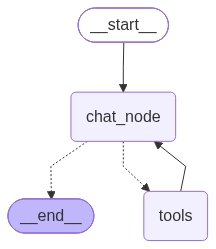

In [41]:
chatbot

In [ ]:
thread_id = "user-1"


while True:

    msg = input()

    if msg in ["bye", "exit"]:
        break

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    initial_state = {
        "messages": [HumanMessage(content=(msg))]
    }

    resp = chatbot.invoke(initial_state, config)

    # check for approval
    if resp.get("__interrupt__"):
        print("⏸️ Waiting for human approval")
        print(resp["__interrupt__"])

        # request to user for approval
        approval = input(resp["__interrupt__"])

        # resume the process
        resp = chatbot.invoke(Command(resume={"approved": approval}), config)

    print("\nuser: ", msg)
    print("AI: ", resp["messages"][-1].content)



Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


⏸️ Waiting for human approval
[Interrupt(value={'message': 'need the confirmation for Placing order dor rs: 899.0', 'cart_id': 'cart_12345', 'payment_method': 'credit_card'}, id='303bf7b4d33793e4b8616e5466183067')]


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')



user:  place order for p102
AI:  [{'type': 'text', 'text': "I'm sorry, but your payment for the Dell XPS 13 (p102) was not approved. Please check your payment information or try a different payment method.", 'extras': {'signature': 'EnEKbwERTTIPps6cgTTqMUlQPna6lZLW2xQKPNxyQM9L+iJx+i7BBMvdrpKEDDE/+9UTnmQ4rdk3hfs3F0UEaGf1IzlNc7q0/J4Gnh/Gy5jUPhi3vIYj8+cf9aTupAkTE6eQZVBeQvBbBFW0n2jy5VXNkg=='}}]


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [ ]:
# test the HITL
if True:
    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    initial_state = {
        "messages": [HumanMessage(content=(msg))]
    }

    resp = chatbot.invoke(Command(resume={"approved": "yes"}), config)

    if resp.get("__interrupt__"):
        print("⏸️ Waiting for human approval")
        print(resp["__interrupt__"])

    print(resp)

    print("\nAI: ", resp["messages"][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='place order of MacBook Air M3', additional_kwargs={}, response_metadata={}), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'fetch_products_list', 'arguments': '{"category": "laptops"}'}, '__gemini_function_call_thought_signatures__': {'call_478706': 'EnEKbwERTTIPRg009KSvzSCKKg3v1PfpAAKNX7+QdfvEoGGzPsBEt6loq5HaPK0Bflvgghbq55eTtRhT8cAIz/mPEifkkc+ZK9zs/LGKG0kgDwiKEx/WHKvAKq5quoeUzBpL01+ZZY/UcYA6FagOEvhw5A=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a01b84-27f2-72c2-b626-ee9dfd06a63a-0', tool_calls=[{'name': 'fetch_products_list', 'args': {'category': 'laptops'}, 'id': 'call_478706', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 253, 'output_tokens': 19, 'total_tokens': 272, 'input_token_details': {'cache_read': 0}}), ToolMessage(content=[], name='fetch_products_list', tool_call_id='call_

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


# Types of HITL (Human-in-the-Loop) Workflow

In Human-in-the-Loop (HITL) workflows, the main difference is what the human does and where the workflow pauses.

### 1. Based on Workflow Structure

1. Single Interrupt
2. Sequential Multiple Interrupts
3. Parallel Multiple Interrupts
4. Nested Interrupts

### 2. Based on Human Action

5. Approval / Rejection
6. Human Input / Information Gathering
7. Human Selection / Decision
8. Human Correction / Editing
9. Human Override
10. Human Feedback / Evaluation

### 3. Based on When Human Gets Involved

11. Pre-Execution Review
12. Tool Execution Approval
13. Mid-Workflow Intervention
14. Post-Execution Review
15. Exception-Based Intervention
16. Escalation to Human

### 4. Based on Number of Humans

17. Single-Human HITL
18. Multiple-Human / Multi-Reviewer HITL
19. Sequential Multi-Reviewer
20. Parallel Multi-Reviewer
21. Consensus-Based HITL

### 5. Agentic HITL Patterns

22. Human-Approved Tool Calling
23. Human-Guided Agent
24. Human-Agent Handoff
25. Human Override of Agent Decision
26. Human Approval Before High-Risk Action
27. Human Feedback → Agent Replanning


